In [2]:
import pandas as pd
import glob
import numpy as np
import protfasta
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo


# 1. Heurisitic - taxonomic levels

In [3]:
prot_align_paths = glob.glob("../data/zoonomia_toga_mca_all_TFs/prot_alignments_with_lambert/*")

In [4]:
overview_table = pd.read_csv("../data/zoonomia_toga_species_overview.tsv", sep = "\t")
overview_table

,Species,Common name,Species Taxonomy ID,Taxonomic Lineage,Assembly name,NCBI accession / source,contig N50 (bp),scaffold N50 (bp)
0,Acinonyx jubatus,cheetah,32536,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLaciJub2,GCF_003709585.1,179924,48500042
1,Acomys cahirinus,Egyptian spiny mouse,10068,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoCah1,GCA_004027535.1,42476,65411
2,Acomys cahirinus,Egyptian spiny mouse,10068,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoCah2,https://zenodo.org/record/7761277#.ZEKxiRVBwsw,57643754,127770522
3,Acomys dimidiatus,Eastern spiny mouse,60744,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoDim1,GCA_907164435.1,33040,124365287
4,Acomys russatus,golden spiny mouse,60746,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoRus1,GCA_903995435.1,4450755,66475698
...,...,...,...,...,...,...,...,...
553,Vulpes vulpes,red fox,9627,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLvulVul2,DNA Zoo Consortium,53406,139030359
554,Xerus inauris,South African ground squirrel,234690,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLxerIna1,GCA_004024805.1,64054,83865
555,Zalophus californianus,California sea lion,9704,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLzalCal1,GCA_009762305.1,60554208,146931682
556,Zapus hudsonius,meadow jumping mouse,160400,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLzapHud1,GCA_004024765.1,23350,26350


In [5]:
# What is max number of levels in taxonomic lineage?

max_levels = 0

for i in range(len(overview_table)):
    max_levels = max(max_levels, overview_table["Taxonomic Lineage"].iloc[i].count(";"))

max_levels + 1

14

In [6]:
for i in np.arange(14):
    overview_table[i] = overview_table["Taxonomic Lineage"].str.split(";").str[i]
overview_table

,Species,Common name,Species Taxonomy ID,Taxonomic Lineage,Assembly name,NCBI accession / source,contig N50 (bp),scaffold N50 (bp),0,1,...,4,5,6,7,8,9,10,11,12,13
0,Acinonyx jubatus,cheetah,32536,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLaciJub2,GCF_003709585.1,179924,48500042,Mammalia,Theria,...,Laurasiatheria,Carnivora,Feliformia,Felidae,Acinonychinae,Acinonyx,NaN,NaN,NaN,NaN
1,Acomys cahirinus,Egyptian spiny mouse,10068,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoCah1,GCA_004027535.1,42476,65411,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Muroidea,Muridae,Deomyinae,Acomys,NaN,NaN
2,Acomys cahirinus,Egyptian spiny mouse,10068,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoCah2,https://zenodo.org/record/7761277#.ZEKxiRVBwsw,57643754,127770522,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Muroidea,Muridae,Deomyinae,Acomys,NaN,NaN
3,Acomys dimidiatus,Eastern spiny mouse,60744,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoDim1,GCA_907164435.1,33040,124365287,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Muroidea,Muridae,Deomyinae,Acomys,NaN,NaN
4,Acomys russatus,golden spiny mouse,60746,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoRus1,GCA_903995435.1,4450755,66475698,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Muroidea,Muridae,Deomyinae,Acomys,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,Vulpes vulpes,red fox,9627,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLvulVul2,DNA Zoo Consortium,53406,139030359,Mammalia,Theria,...,Laurasiatheria,Carnivora,Caniformia,Canidae,Vulpes,NaN,NaN,NaN,NaN,NaN
554,Xerus inauris,South African ground squirrel,234690,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLxerIna1,GCA_004024805.1,64054,83865,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Sciuromorpha,Sciuridae,Xerinae,Xerini,Xerus,NaN,NaN
555,Zalophus californianus,California sea lion,9704,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLzalCal1,GCA_009762305.1,60554208,146931682,Mammalia,Theria,...,Laurasiatheria,Carnivora,Caniformia,Otariidae,Zalophus,NaN,NaN,NaN,NaN,NaN
556,Zapus hudsonius,meadow jumping mouse,160400,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLzapHud1,GCA_004024765.1,23350,26350,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Dipodoidea,Dipodidae,Zapodinae,Zapus,NaN,NaN


In [7]:
for i in np.arange(14):
    print("Level " + str(i))
    print(overview_table[i].value_counts())
    print(str(sum(overview_table[i].isna())) + " nulls")
    print()

Level 0
0
Mammalia    558
Name: count, dtype: int64
0 nulls

Level 1
1
Theria         554
Prototheria      4
Name: count, dtype: int64
0 nulls

Level 2
2
Eutheria       533
Metatheria      21
Monotremata      4
Name: count, dtype: int64
0 nulls

Level 3
3
Boreoeutheria        509
Afrotheria            15
Diprotodontia         14
Xenarthra              9
Dasyuromorphia         3
Didelphimorphia        3
Ornithorhynchidae      2
Tachyglossidae         2
Microbiotheria         1
Name: count, dtype: int64
0 nulls

Level 4
4
Laurasiatheria       325
Euarchontoglires     184
Pilosa                 7
Sirenia                4
Macropodidae           4
Hyracoidea             3
Pseudocheiridae        3
Phalangeridae          3
Didelphidae            3
Tachyglossus           2
Tubulidentata          2
Ornithorhynchus        2
Proboscidea            2
Petauridae             2
Tenrecidae             2
Cingulata              2
Dasyuridae             2
Macroscelidea          1
Microbiotheriidae      1

In [8]:
# Strategy: count how many level 4 classes are included for each protein

In [9]:
len(overview_table[1].value_counts())

2

In [10]:
class_counts = dict()

for taxon_class in np.arange(5):
    class_counts[taxon_class] = []
    
    for path in prot_align_paths:
        # Read in names
        protein_species = protfasta.read_fasta(path, invalid_sequence_action='ignore').keys()
        protein_species = pd.DataFrame(protein_species)
        protein_species[0] = protein_species[0].str.split("_").str[1].str.split("\t").str[0]
    
        # Merge names with more info about protein - including taxonomic
        protein_species_info = overview_table[overview_table["Assembly name"].isin(protein_species[0])]
    
        # Get number in class 4
        class_counts[taxon_class].append(len(protein_species_info[taxon_class].value_counts()))

In [11]:
from matplotlib.ticker import MaxNLocator

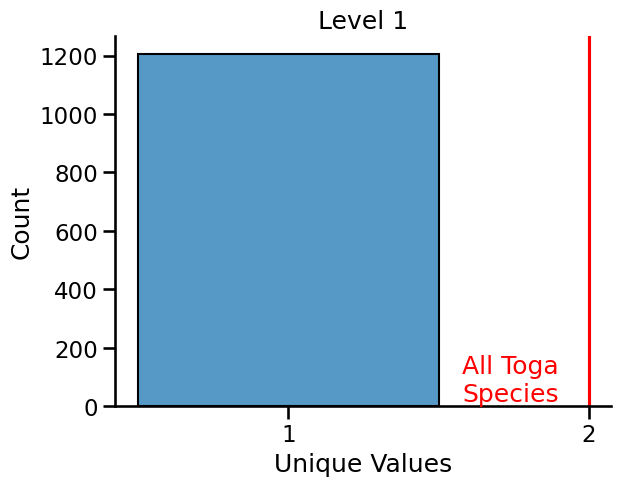

Level 1
1
Theria         554
Prototheria      4
Name: count, dtype: int64
0 nulls



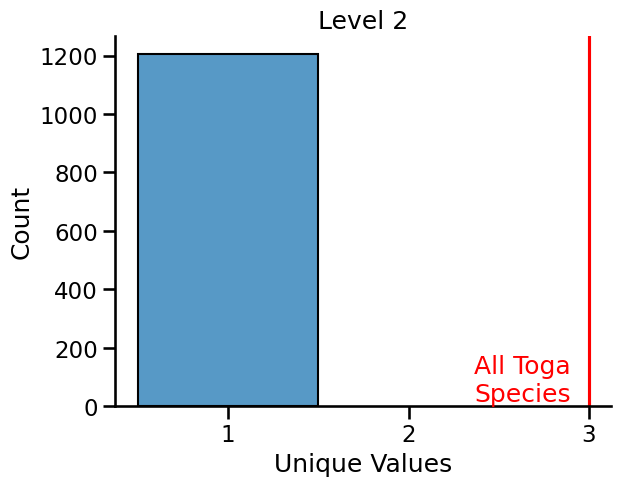

Level 2
2
Eutheria       533
Metatheria      21
Monotremata      4
Name: count, dtype: int64
0 nulls



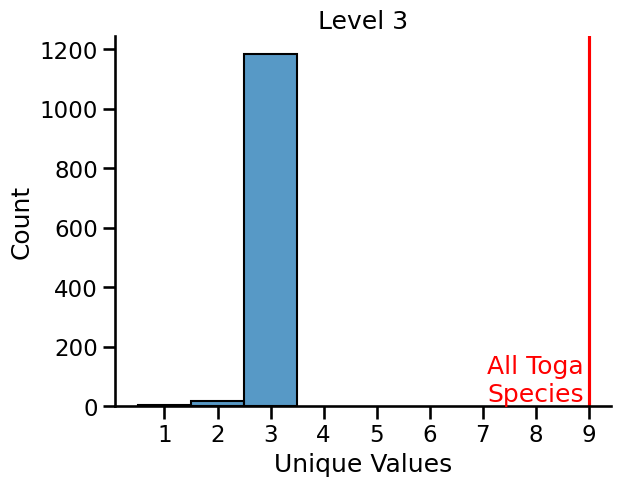

Level 3
3
Boreoeutheria        509
Afrotheria            15
Diprotodontia         14
Xenarthra              9
Dasyuromorphia         3
Didelphimorphia        3
Ornithorhynchidae      2
Tachyglossidae         2
Microbiotheria         1
Name: count, dtype: int64
0 nulls



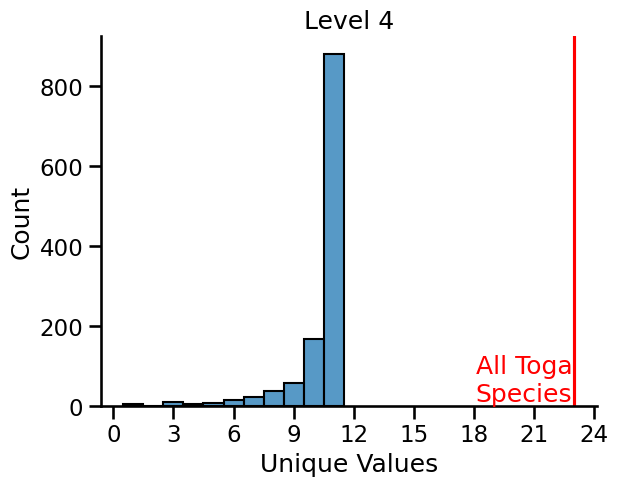

Level 4
4
Laurasiatheria       325
Euarchontoglires     184
Pilosa                 7
Sirenia                4
Macropodidae           4
Hyracoidea             3
Pseudocheiridae        3
Phalangeridae          3
Didelphidae            3
Tachyglossus           2
Tubulidentata          2
Ornithorhynchus        2
Proboscidea            2
Petauridae             2
Tenrecidae             2
Cingulata              2
Dasyuridae             2
Macroscelidea          1
Microbiotheriidae      1
Phascolarctidae        1
Chrysochloridae        1
Thylacinidae           1
Vombatidae             1
Name: count, dtype: int64
0 nulls



In [12]:
sns.set_context('talk')

for i in np.arange(1, 5):
    ax = sns.histplot(class_counts[i], discrete = True)
    plt.axvline(len(overview_table[i].value_counts()), color = 'red')
    plt.text(x = len(overview_table[i].value_counts()) - 0.1, y = 0, s = "All Toga\nSpecies", color = 'red', ha = 'right', va = 'bottom')
    sns.despine()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlabel("Unique Values")
    plt.title("Level " + str(i))
    plt.show()
    print("Level " + str(i))
    print(overview_table[i].value_counts())
    print(str(sum(overview_table[i].isna())) + " nulls")
    print()
    

# 2. Percent identity vs # species

In [13]:
percent_identity_paths = glob.glob("../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/*")
percent_identity_paths[:3]

['../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/ARID3C',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/DMRTA2',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/REXO4']

In [14]:
prot_align_paths[:3]

['../data/zoonomia_toga_mca_all_TFs/prot_alignments_with_lambert/ZBTB17.fasta',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignments_with_lambert/TP63.fasta',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignments_with_lambert/RARG.fasta']

In [15]:
known_ADs = pd.read_csv("../output/known_ADs_considering_isoforms_and_canonical_with_alerasool.csv")
known_ADs

,Unnamed: 0,Gene,Start,End,uniprotID,Matching Isoforms,Canonical Transcript ID,orig_uniprotID,Reference,TileType,ProteinRegionSeq
0,0,ABRAXAS1,121,200,Q6UWZ7,[['Q6UWZ7']],ENST00000321945,Q6UWZ7,"DelRosso et al. (Q6UWZ7, 121_200)",CR,LQEHFSNQDLVFLLLTPSIITESCSTHRLEHSLYKPQKGLFHRVPL...
1,1,AHR,118,126,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,LLQALNGFV
2,2,AHR,266,268,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,FAI
3,3,AHR,532,848,P35869,"[['P35869'], ['P35869'], ['P35869']]",ENST00000242057 / nan / ENST00000242057,P35869 / P35869 / P35869,"DelRosso et al. (P35869, 532_641) // PMID: 879...",TF / TF / TF,QDSKNSDLYSIMKNLGIDFEDIRHMQNEKFFRNDFSGEVDFRDIDL...
4,4,AKAP8,2,81,O43823,[['O43823']],ENST00000269701,O43823,"DelRosso et al. (O43823, 2_81)",TF,DQGYGGYGAWSAGPANTQGAYGTGVASWQGYENYNYYGAQNTSVTT...
...,...,...,...,...,...,...,...,...,...,...,...
756,757,ATXN7L3,1,120,Q14CW9,"[['Q14CW9', 'Q14CW9-2']]",NaN,NaN,Alerasool et al,TF,MKMEEMSLSGLDNSKLEAIAQEIYADLVEDSCLGFCFEVHRAVKCG...
757,758,FAM22F,361,500,A1L443,[['A1L443']],NaN,NaN,Alerasool et al,TF,PRPQRPAETNAHLPPPRPQRPAETKVPEEIPPEVVQEYVDIMEELL...
758,759,SS18L2,18,77,Q9UHA2,[['Q9UHA2']],NaN,NaN,Alerasool et al,TF,QETIQRLLEENDQLIRCIVEYQNKGRGNECVQYQHVLHRNLIYLAT...
759,760,SERTAD2,201,260,Q14140,[['Q14140']],NaN,NaN,Alerasool et al,TF,SEAGTQKLDGPQESRADDSKLMDSLPGNFEITTSTGFLTDLTLDDI...


In [16]:
avg_perc_idents = []
num_species = []
activator_status = []

for path in prot_align_paths:
    gene_name = path.split("/")[-1].split(".")[0]

    percent_identity_path = "../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/" + gene_name
    
    if percent_identity_path in percent_identity_paths:
        avg_perc_idents.append(np.average(pd.read_csv(percent_identity_path)["percent_identity"]))
        num_species.append(len(protfasta.read_fasta(path, invalid_sequence_action='ignore')))
        activator_status.append(gene_name in known_ADs["Gene"].values)

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_31880/1260488559.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = "Activator TF?", bbox_to_anchor = (1,1))


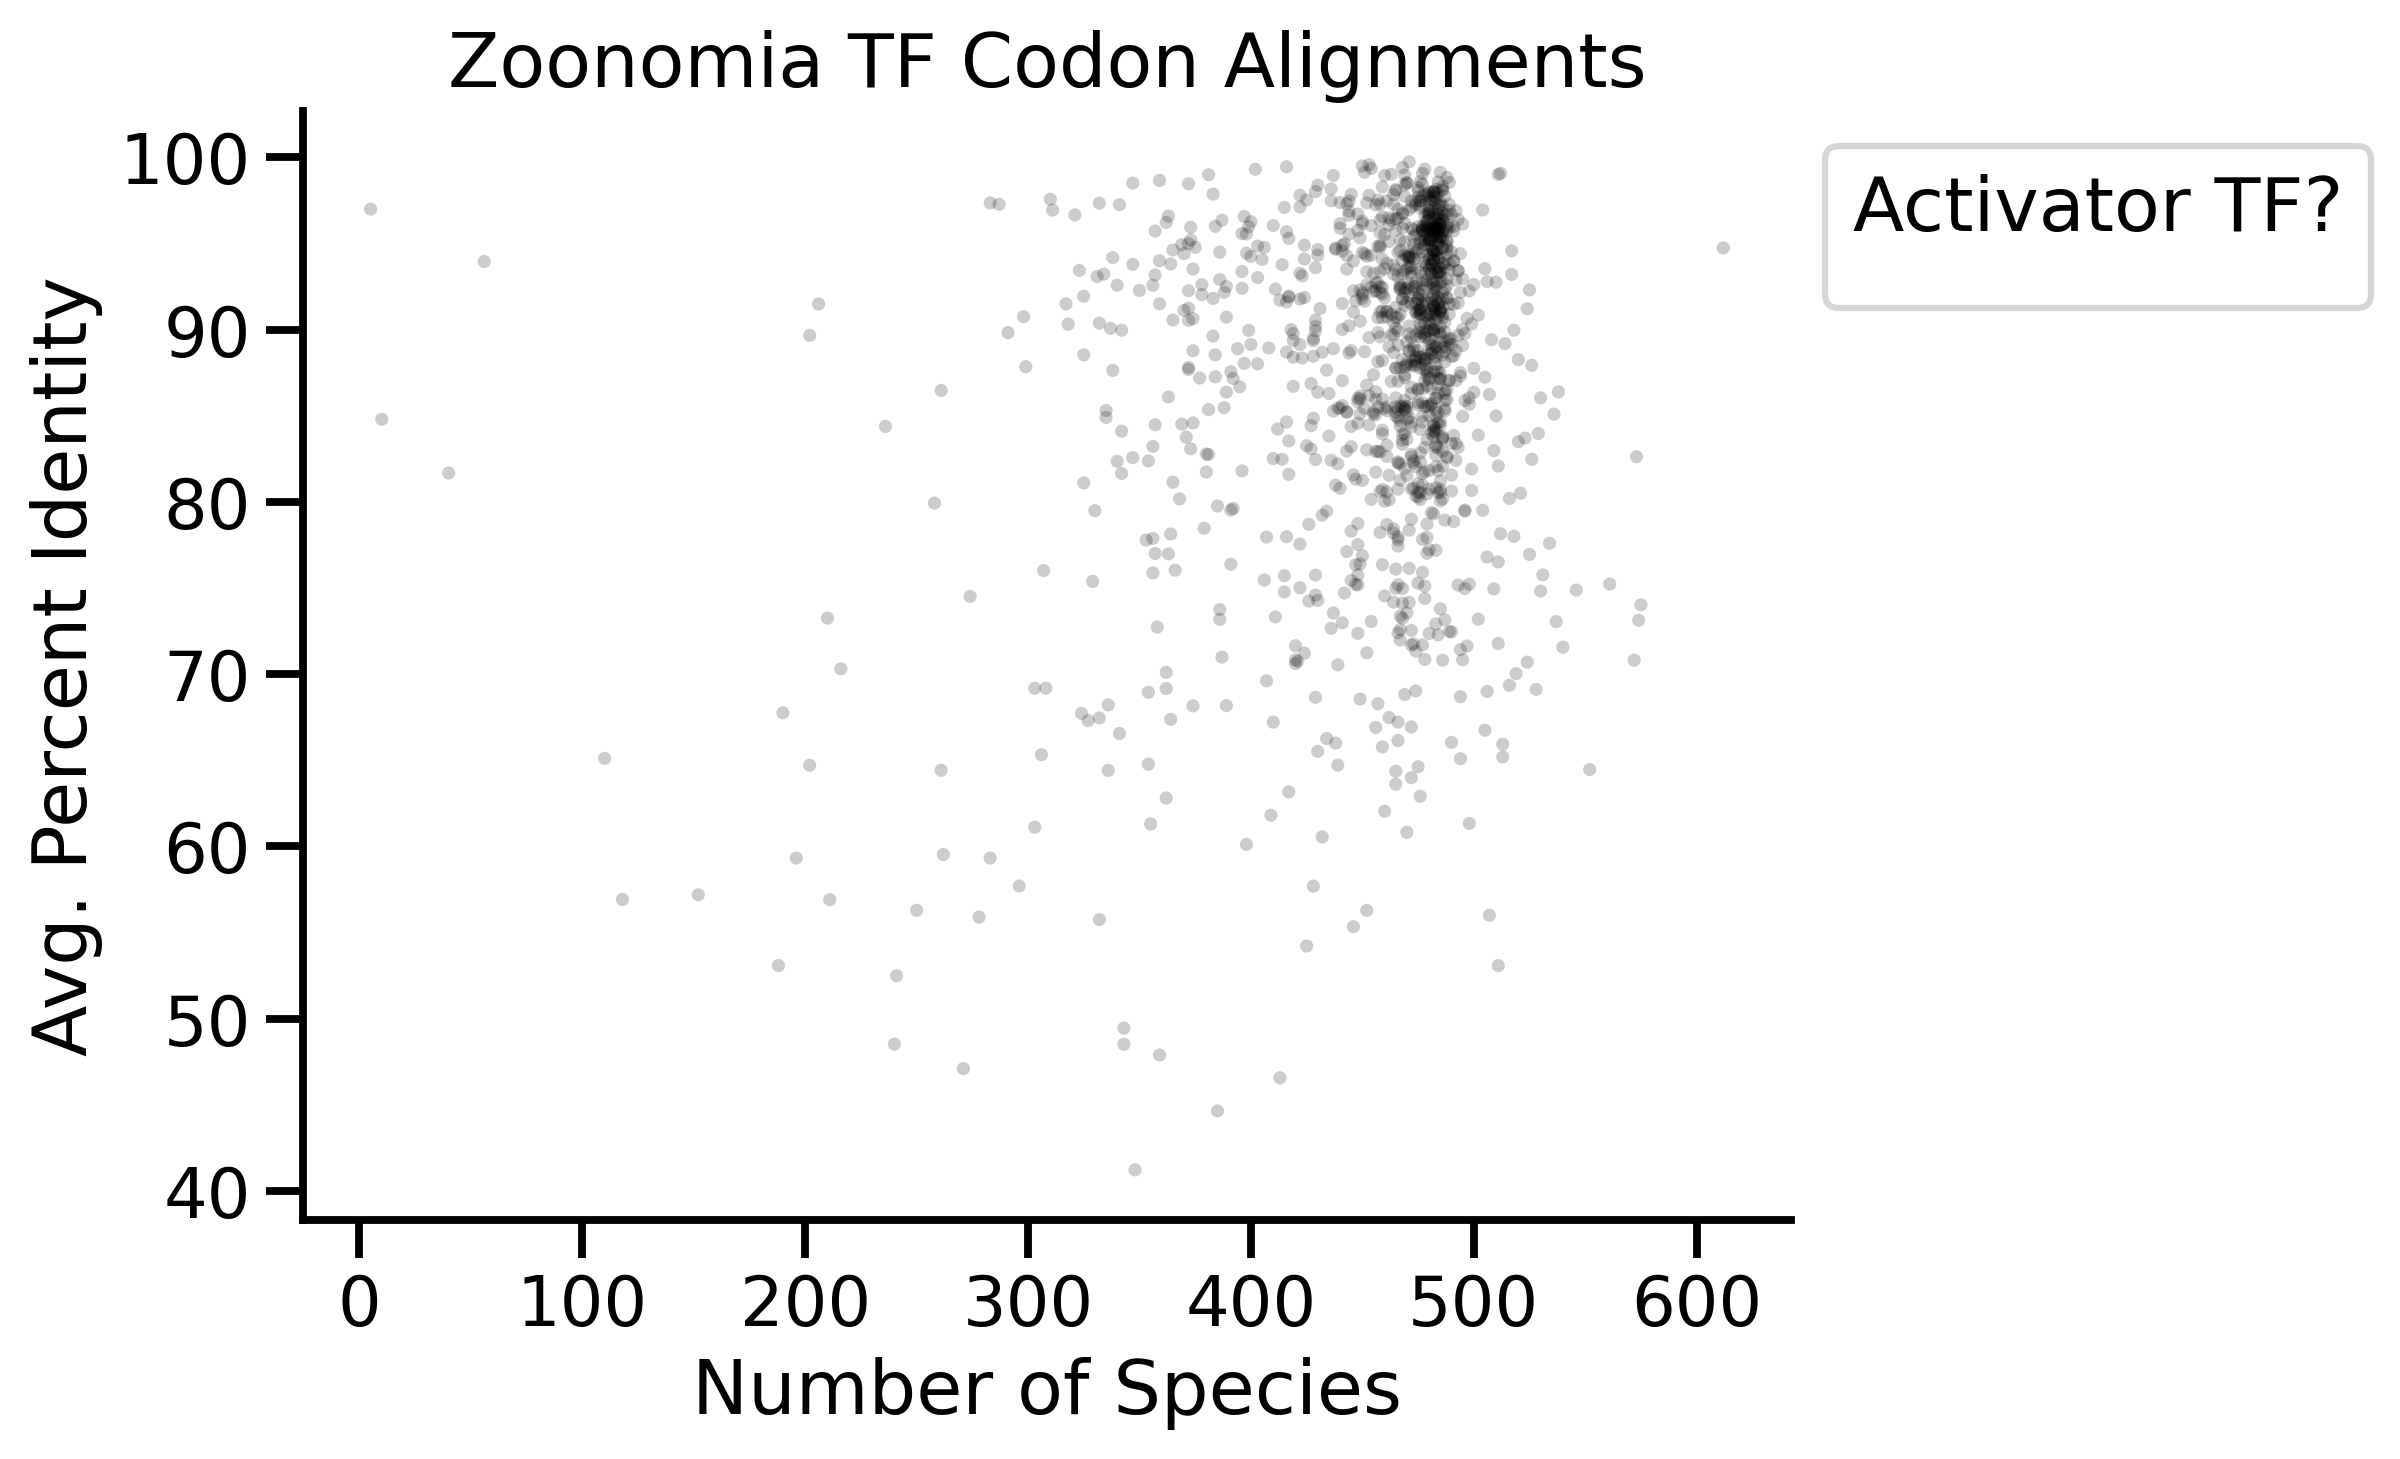

In [17]:
plt.figure(dpi = 300)
sns.scatterplot(x = num_species, y = avg_perc_idents, s = 10, alpha = 0.2, edgecolor = 'none', color = 'black')
plt.xlabel("Number of Species")
plt.ylabel("Avg. Percent Identity")
plt.title("Zoonomia TF Codon Alignments")
plt.legend(title = "Activator TF?", bbox_to_anchor = (1,1))
sns.despine()

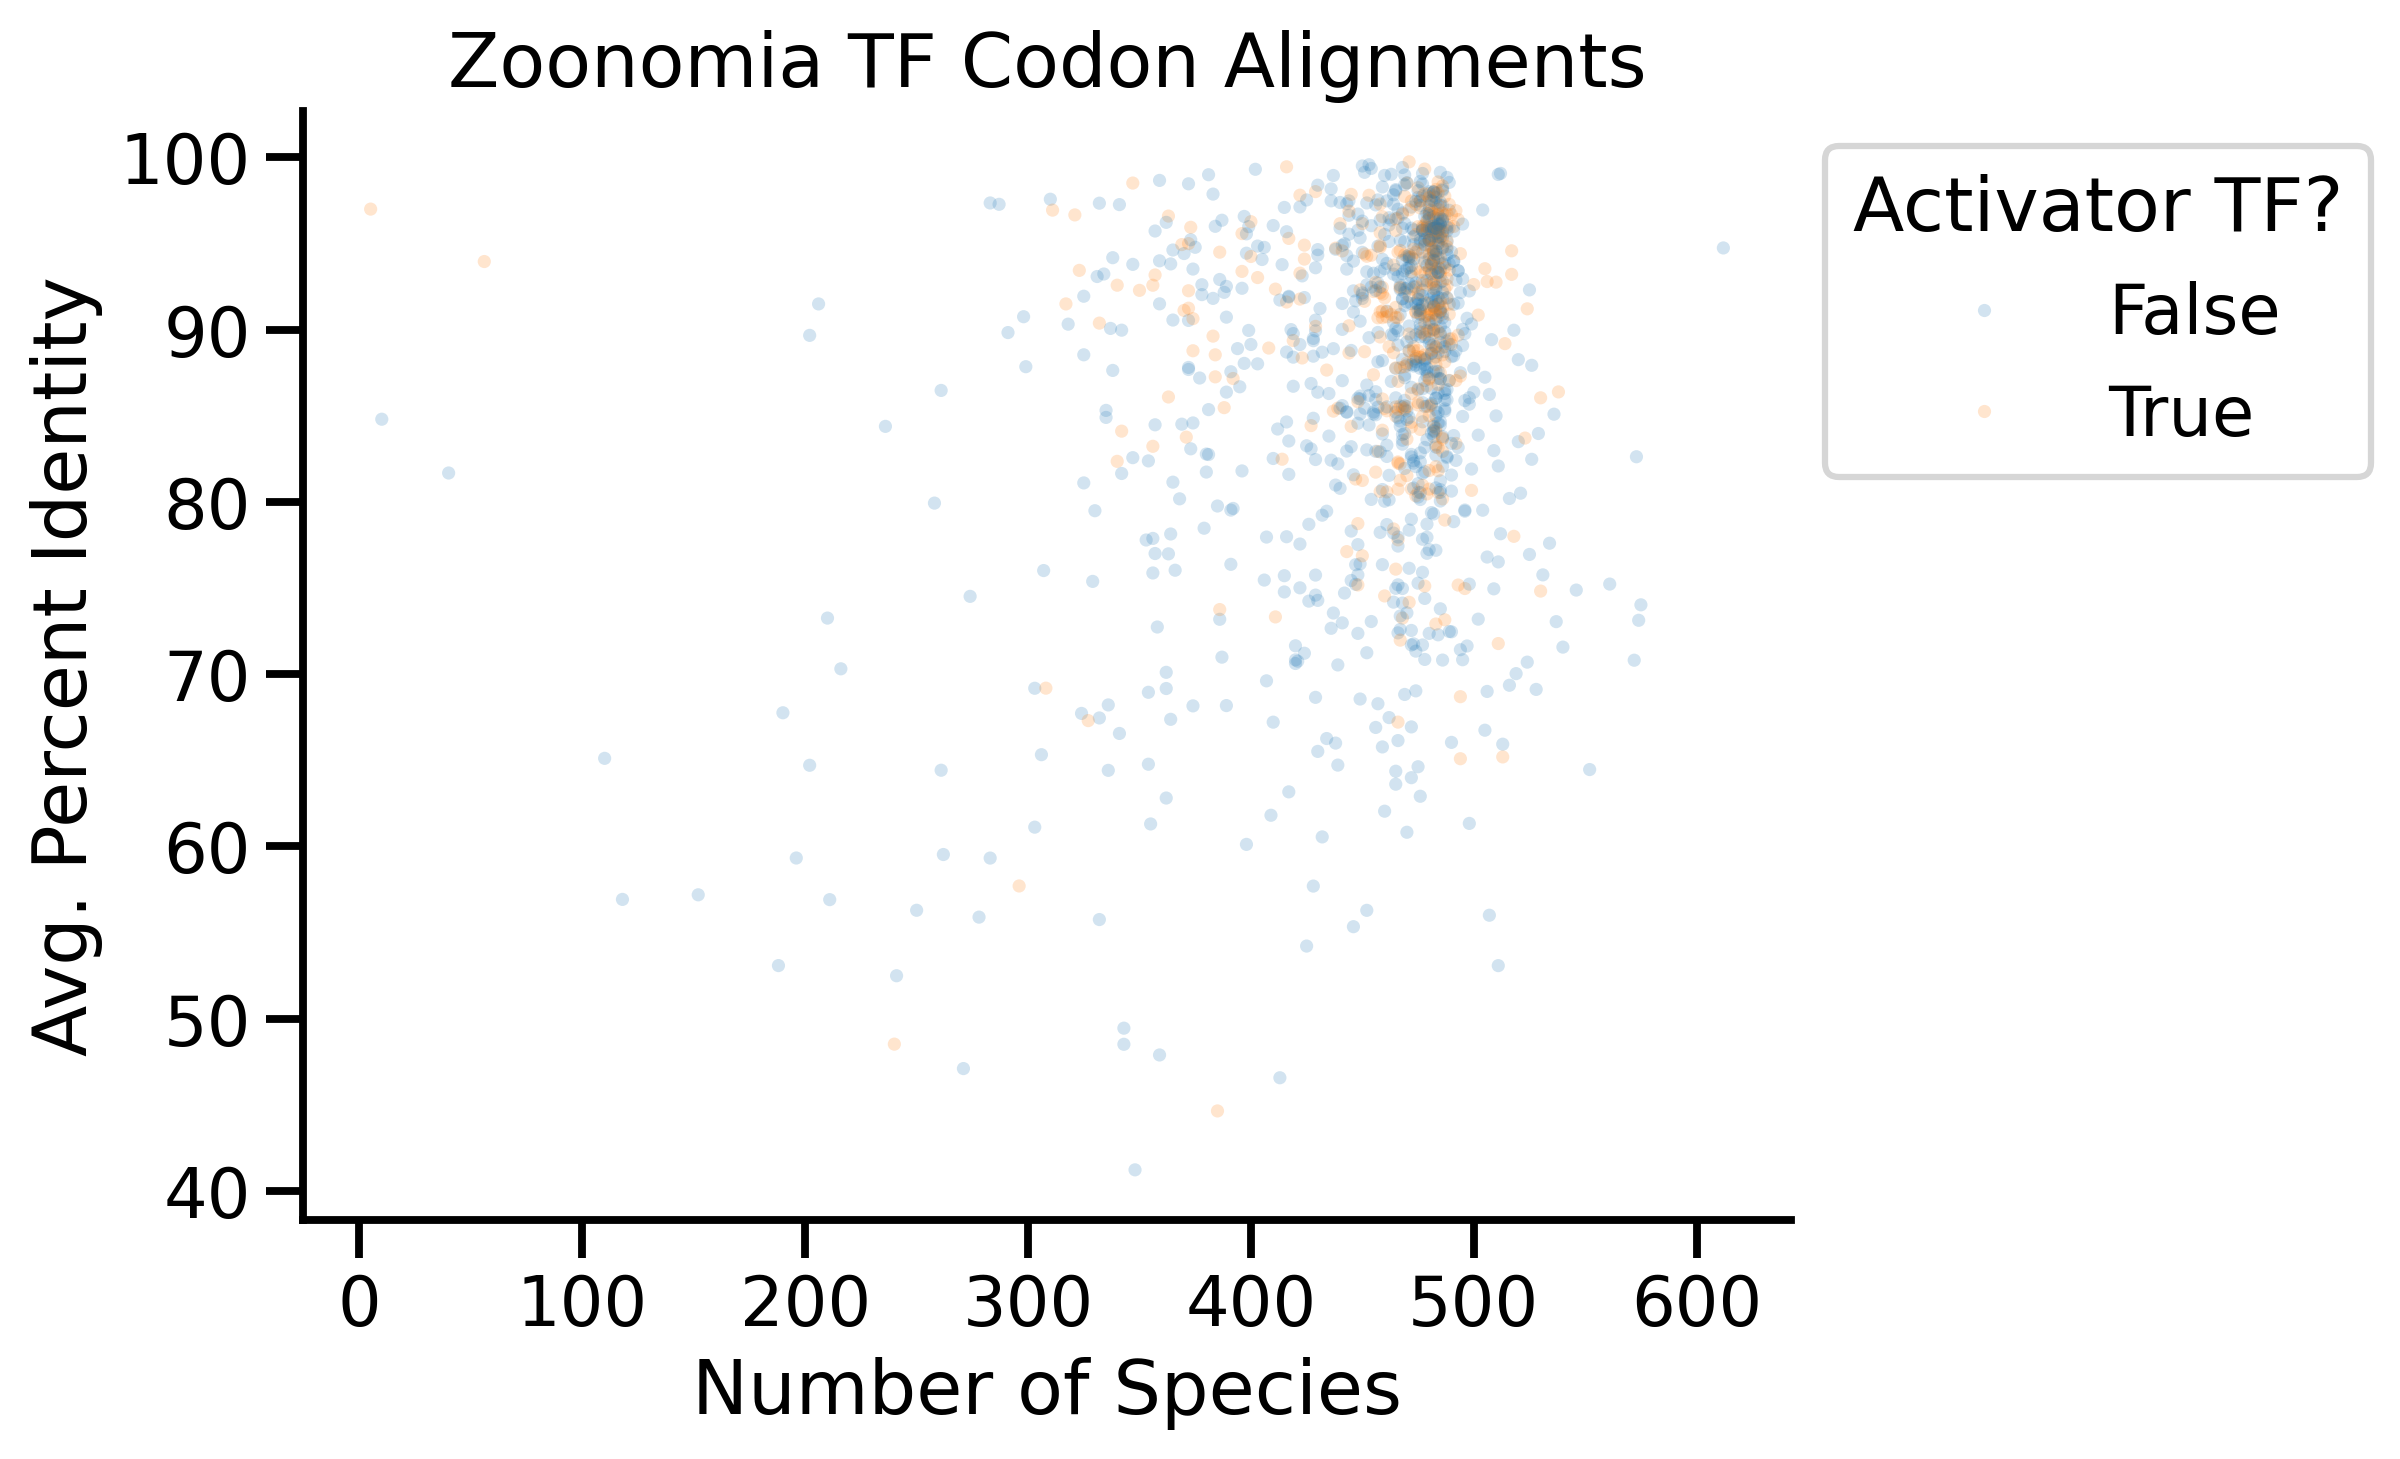

In [18]:
plt.figure(dpi = 300)
sns.scatterplot(x = num_species, y = avg_perc_idents, s = 10, alpha = 0.2, edgecolor = 'none', hue = activator_status)
plt.xlabel("Number of Species")
plt.ylabel("Avg. Percent Identity")
plt.title("Zoonomia TF Codon Alignments")
plt.legend(title = "Activator TF?", bbox_to_anchor = (1,1))
sns.despine()

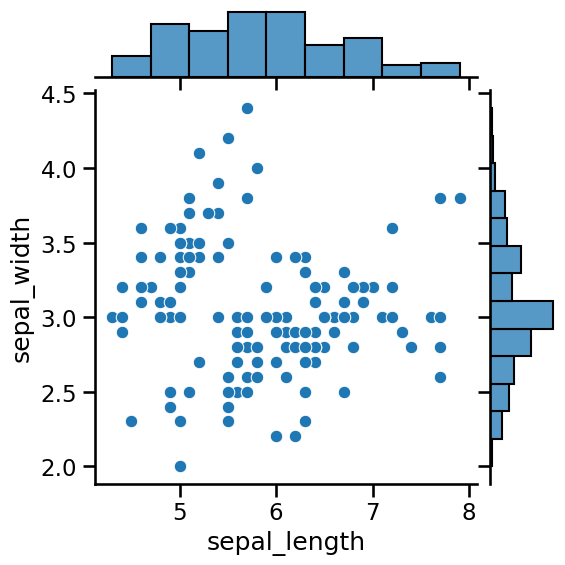

In [35]:
df = sns.load_dataset('iris')
 
# Custom the inside plot: options are: “scatter” | “reg” | “resid” | “kde” | “hex”
sns.jointplot(x=df["sepal_length"], y=df["sepal_width"], kind='scatter')

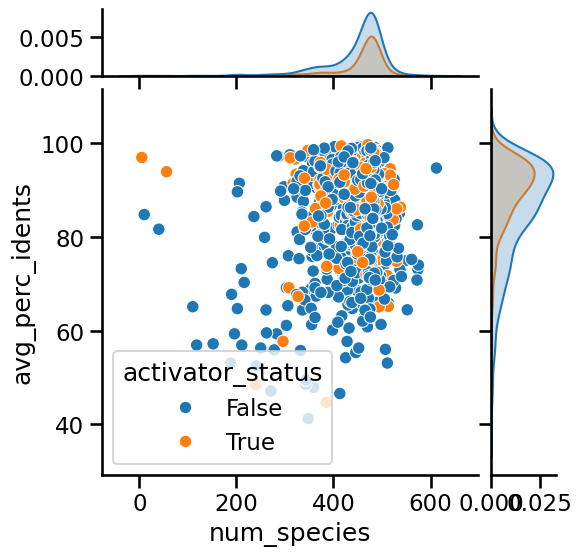

In [37]:
df = pd.DataFrame({
    "num_species": num_species,
    "avg_perc_idents": avg_perc_idents,
    "activator_status": activator_status
})

# Create the jointplot
sns.jointplot(
    data=df,
    x="num_species",
    y="avg_perc_idents",
    hue="activator_status",
    kind="scatter",
    marginal_ticks=True)

plt.show()


<Axes: xlabel='avg_perc_idents', ylabel='Count'>

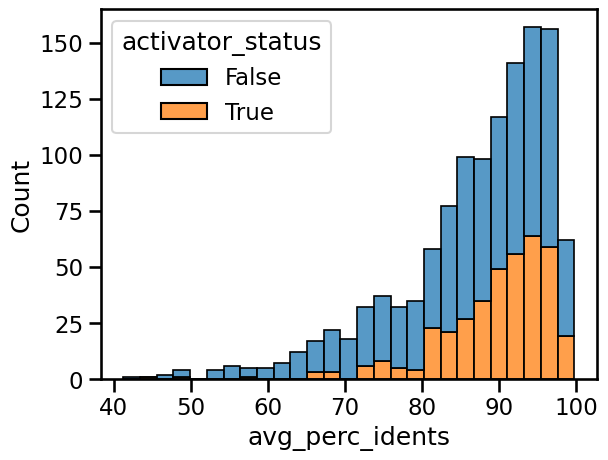

In [39]:
sns.histplot(data = df, x = "avg_perc_idents", hue = "activator_status", multiple = "stack")

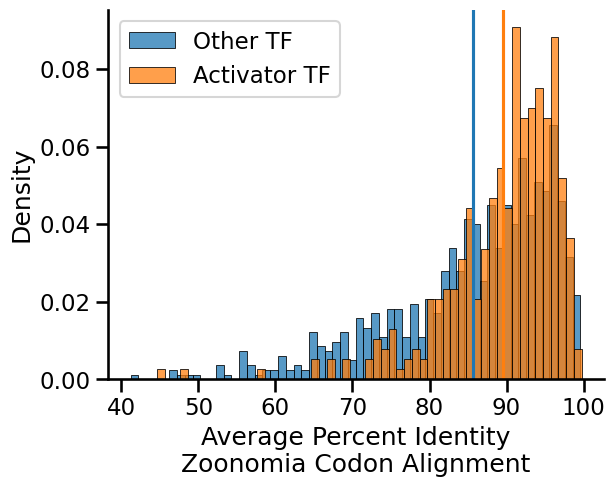

In [58]:
sns.histplot(df[df["activator_status"] == False]["avg_perc_idents"], stat = 'density',  binwidth = 1, color = sns.color_palette('tab10')[0], label = "Other TF")
sns.histplot(df[df["activator_status"] == True]["avg_perc_idents"], stat = 'density', binwidth =1, color = sns.color_palette('tab10')[1], label = "Activator TF")

plt.axvline(np.mean(df[df["activator_status"] == False]["avg_perc_idents"]), color = sns.color_palette('tab10')[0])
plt.axvline(np.mean(df[df["activator_status"] == True]["avg_perc_idents"]), color = sns.color_palette('tab10')[1])

plt.legend()
plt.xlabel("Average Percent Identity\nZoonomia Codon Alignment")
sns.despine()


In [16]:
pd.read_csv("../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/" + "ZBTB17")

,Unnamed: 0,percent_identity,pos
0,0,98.097252,M
1,1,98.097252,D
2,2,98.308668,F
3,3,98.308668,P
4,4,98.097252,Q
...,...,...,...
798,798,89.429175,P
799,799,97.463002,P
800,800,79.281184,P
801,801,95.348837,A


# 3. Visualizing tree

In [17]:
overview_table

,Species,Common name,Species Taxonomy ID,Taxonomic Lineage,Assembly name,NCBI accession / source,contig N50 (bp),scaffold N50 (bp),0,1,...,4,5,6,7,8,9,10,11,12,13
0,Acinonyx jubatus,cheetah,32536,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLaciJub2,GCF_003709585.1,179924,48500042,Mammalia,Theria,...,Laurasiatheria,Carnivora,Feliformia,Felidae,Acinonychinae,Acinonyx,NaN,NaN,NaN,NaN
1,Acomys cahirinus,Egyptian spiny mouse,10068,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoCah1,GCA_004027535.1,42476,65411,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Muroidea,Muridae,Deomyinae,Acomys,NaN,NaN
2,Acomys cahirinus,Egyptian spiny mouse,10068,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoCah2,https://zenodo.org/record/7761277#.ZEKxiRVBwsw,57643754,127770522,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Muroidea,Muridae,Deomyinae,Acomys,NaN,NaN
3,Acomys dimidiatus,Eastern spiny mouse,60744,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoDim1,GCA_907164435.1,33040,124365287,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Muroidea,Muridae,Deomyinae,Acomys,NaN,NaN
4,Acomys russatus,golden spiny mouse,60746,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLacoRus1,GCA_903995435.1,4450755,66475698,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Muroidea,Muridae,Deomyinae,Acomys,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,Vulpes vulpes,red fox,9627,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLvulVul2,DNA Zoo Consortium,53406,139030359,Mammalia,Theria,...,Laurasiatheria,Carnivora,Caniformia,Canidae,Vulpes,NaN,NaN,NaN,NaN,NaN
554,Xerus inauris,South African ground squirrel,234690,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLxerIna1,GCA_004024805.1,64054,83865,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Sciuromorpha,Sciuridae,Xerinae,Xerini,Xerus,NaN,NaN
555,Zalophus californianus,California sea lion,9704,Mammalia; Theria; Eutheria; Boreoeutheria; Lau...,HLzalCal1,GCA_009762305.1,60554208,146931682,Mammalia,Theria,...,Laurasiatheria,Carnivora,Caniformia,Otariidae,Zalophus,NaN,NaN,NaN,NaN,NaN
556,Zapus hudsonius,meadow jumping mouse,160400,Mammalia; Theria; Eutheria; Boreoeutheria; Eua...,HLzapHud1,GCA_004024765.1,23350,26350,Mammalia,Theria,...,Euarchontoglires,Glires,Rodentia,Myomorpha,Dipodoidea,Dipodidae,Zapodinae,Zapus,NaN,NaN


In [18]:
overview_table[["Species Taxonomy ID"]].to_csv("../data/zoonomia_toga_species_IDs.txt", header = None, index = None)

In [28]:
tree1 = Phylo.read("../data/zoonomia_toga_taxon_tree.phy", "newick")
tree1.ladderize()


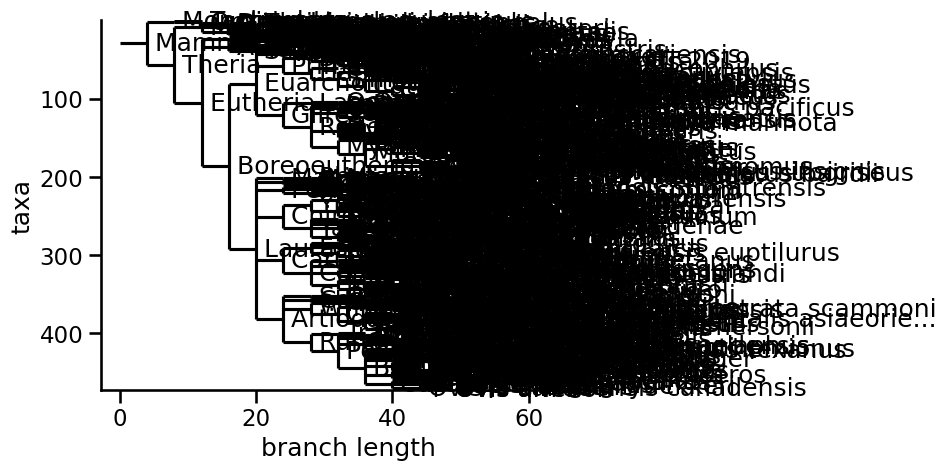

In [29]:
fig, ax = plt.subplots()
sns.despine(ax = ax)
Phylo.draw(tree1, axes = ax)  # Pass axes to the draw function


In [22]:
from ete3 import Tree
#ete3_tree = Tree("../data/zoonomia_toga_taxon_tree.phy", format = 1)
ete3_tree = Tree("../../sog1/data/phyliptree (1).phy", format = 1)


In [23]:
ete3_tree.show()

: 

: 

In [ ]:
from ete3 import Tree, WebTreeApplication
from flask import Flask
from IPython.display import IFrame

app = Flask(__name__)

# Create a tree object
tree = Tree("(A, (B, C));")

# Initialize the WebTreeApplication correctly by passing the tree as a keyword argument
webtree = WebTreeApplication()

# Set the tree for the webtree object
webtree.tree = tree

@app.route('/')
def tree_view():
    return webtree.render()

if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)

IFrame("http://localhost:5000", width=800, height=600)



 * Serving Flask app '__main__'
 * Debug mode: on
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
